# UV and DV PDF Neural Network Training

This notebook trains a neural network to approximate the first JAMPDF plot, focusing on the up-valence (`uv`) and down-valence (`dv`) quark distributions.

The neural network learns the mapping:

`(log_x, log_Q2) -> [xf_uv(x, Q2), xf_dv(x, Q2)]`

The model is trained on the median of the PDF replicas for each `(x, Q²)`. The median gives a smoother central target curve, while the full set of replicas is still used later to construct the 95% uncertainty bands.

The notebook first trains the model on the full `x` domain, then evaluates its performance using visual comparison, coverage inside the 95% PDF band, error as a function of `x`, and leave-one-Q²-out validation.

Finally, I add a limited `x`-domain experiment to study how the model behaves when part of the `x` range is removed from training. This tests whether the network can reproduce the correct PDF shape outside the region where it was trained.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import zipfile
import copy
import time
from google.colab import drive
import random

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


### Loading the PDF dataset

In this cell, I load the PDF data from the `.zip` file.  
The file contains precomputed parton distribution function values. These values describe how quarks share the momentum inside the proton.

The object `treypdf` stores the PDF values for different values of `Q²` and for different quark flavors, such as `uv` and `dv`.

In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [3]:
zip_path = '/content/drive/MyDrive/Colab Notebooks/Summer NN/trey24_no_sidis_lo.zip'

with zipfile.ZipFile(zip_path, 'r') as z:
    print("Files inside zip:", z.namelist())

    with z.open('trey24_no_sidis_lo.npy') as f:
        treypdf = np.load(f, allow_pickle=True).item()

print("Loaded treypdf successfully.")
print("Available Q2 values:", list(treypdf.keys()))
print("Available flavors:", list(treypdf[list(treypdf.keys())[0]].keys()))

Files inside zip: ['trey24_no_sidis_lo.npy']
Loaded treypdf successfully.
Available Q2 values: [1.6129, 10, 100, 500, 1000]
Available flavors: ['uv', 'dv', 'ub', 'db', 's', 'sb', 'c', 'cb', 'b', 'bb', 'g']


### Creating the x values

In this cell, I recreate the same `x` grid used in the original JAMPDF plot.  
The variable `x` represents the fraction of the proton's momentum carried by a quark.

The first part of the grid uses logarithmic spacing from very small `x` values to `0.4`, because PDFs change rapidly at small `x`.  
The second part uses linear spacing from `0.4` to `1`, where the behavior is less compressed.

In [4]:
X = 10**np.linspace(-4, np.log10(0.4), 100)
X = np.append(X, np.linspace(0.4, 1, 101)[1:])

Q2_vals = [1.6129, 10, 100, 500, 1000]

N_x = len(X)

print("Number of x values:", N_x)
print("x min:", X.min())
print("x max:", X.max())

Number of x values: 200
x min: 0.0001
x max: 1.0


### Checking the shape of the data

In this cell, I check the shape of the `uv` and `dv` arrays.  
Here, `uv` means up-valence quark distribution, and `dv` means down-valence quark distribution.

The rows represent PDF replicas, which are different possible versions of the same distribution.  
The columns correspond to the different `x` values.  
This helps confirm how the data is organized before training the neural network.

In [5]:
q2_test = Q2_vals[0]

uv_sample = treypdf[q2_test]['uv']
dv_sample = treypdf[q2_test]['dv']

print("uv shape:", uv_sample.shape)
print("dv shape:", dv_sample.shape)

N_replicas, N_x = uv_sample.shape

print("Number of replicas:", N_replicas)
print("Number of x points:", N_x)

uv shape: (1196, 200)
dv shape: (1196, 200)
Number of replicas: 1196
Number of x points: 200


### Preparing the training and validation data

In this cell, I prepare the data for supervised learning.  
The neural network will receive two inputs: `log(x)` and `log(Q²)`.  
It will learn to predict two outputs: the median `uv` value and the median `dv` value.

I use the median of the replicas because each replica is a possible version of the PDF.  
The median gives a central curve that is easier for the network to learn.

I also hold out `Q² = 500` for validation.  
This means the model trains on the other `Q²` values and is then tested on a value it has not directly seen during training.

In [6]:
VAL_Q2 = 500.0

log_x = np.log(X)

train_inputs = []
train_targets = []

val_inputs = []
val_targets = []

for q2 in Q2_vals:
    uv = treypdf[q2]['uv']   # shape: (N_replicas, N_x)
    dv = treypdf[q2]['dv']   # shape: (N_replicas, N_x)

    # Median curve across replicas
    uv_median = np.median(uv, axis=0)
    dv_median = np.median(dv, axis=0)

    # Input: [log(x), log(Q2)]
    inputs = np.stack([
        log_x,
        np.full_like(log_x, np.log(q2))
    ], axis=1)

    # Target: [uv, dv]
    targets = np.stack([
        uv_median,
        dv_median
    ], axis=1)

    if q2 == VAL_Q2:
        val_inputs.append(inputs)
        val_targets.append(targets)
    else:
        train_inputs.append(inputs)
        train_targets.append(targets)

train_X = torch.tensor(np.concatenate(train_inputs), dtype=torch.float32).to(device)
train_Y = torch.tensor(np.concatenate(train_targets), dtype=torch.float32).to(device)

val_X = torch.tensor(np.concatenate(val_inputs), dtype=torch.float32).to(device)
val_Y = torch.tensor(np.concatenate(val_targets), dtype=torch.float32).to(device)

print("train_X:", train_X.shape)
print("train_Y:", train_Y.shape)
print("val_X:", val_X.shape)
print("val_Y:", val_Y.shape)

train_X: torch.Size([800, 2])
train_Y: torch.Size([800, 2])
val_X: torch.Size([200, 2])
val_Y: torch.Size([200, 2])


### Defining the neural network

In this cell, I define the neural network architecture.  
The model takes two inputs: `log(x)` and `log(Q²)`.  
It outputs two values: the predicted `uv` and `dv` distributions.

The hidden layers allow the model to learn nonlinear relationships between the input variables and the PDF values.  
The final layer has two outputs because the model predicts both the up-valence and down-valence distributions.

The `Softplus` activation is used at the end to keep the predictions positive, which makes sense because PDF values should not be negative.

In [7]:
class PDFNN(nn.Module):
    """
    Input:  [log(x), log(Q2)]
    Output: [xf_uv(x,Q2), xf_dv(x,Q2)]
    """

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.Tanh(),

            nn.Linear(64, 128),
            nn.Tanh(),

            nn.Linear(128, 64),
            nn.Tanh(),

            nn.Linear(64, 2),
            nn.Softplus()
        )

        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)

    def forward(self, x):
        return self.net(x)


model = PDFNN().to(device)

print(model)
print("Number of parameters:", sum(p.numel() for p in model.parameters()))

PDFNN(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): Tanh()
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): Tanh()
    (6): Linear(in_features=64, out_features=2, bias=True)
    (7): Softplus(beta=1.0, threshold=20.0)
  )
)
Number of parameters: 16898


### Training the neural network

In this cell, I train the neural network. During training, the model makes predictions, compares them with the median `uv` and `dv` target values, calculates the loss, and updates its weights to reduce that loss.

In this version, I use a mixed loss that combines standard MSE and softened relative MSE:

`0.7 * MSE + 0.3 * relative_loss`

The purpose of this loss is to reduce the bias of standard MSE toward regions where the PDF values are larger. Standard MSE measures absolute error, so larger PDF regions can dominate the training. Relative MSE instead measures the error compared to the size of the target value.

The MSE term helps preserve the overall PDF shape, while the relative-loss term helps reduce bias toward regions where the PDF values are larger.

The small `eps` term prevents division by zero or by values that are too close to zero. Without this term, the loss can become unstable in regions where `uv` or `dv` are very small.

The validation loss tracks how well the model performs at the held-out scale `Q² = 500`.

In [8]:
BATCH_SIZE = 512
N_EPOCHS = 10000
LOG_EVERY = 500
EARLY_STOP_PATIENCE = 1500

optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
def mixed_loss(pred, target, alpha=0.7, eps=1e-3):
    mse = torch.mean((pred - target)**2)
    rel = torch.mean(((pred - target) / (torch.abs(target) + eps))**2)
    return alpha * mse + (1 - alpha) * rel

loss_fn = mixed_loss

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.7,
    patience=300,
    min_lr=1e-6
)

train_losses = []
val_losses = []

best_val_loss = float("inf")
best_state = None
no_improve = 0

N_train = train_X.shape[0]
n_batches = (N_train + BATCH_SIZE - 1) // BATCH_SIZE

start_time = time.time()

for epoch in range(1, N_EPOCHS + 1):

    model.train()

    permutation = torch.randperm(N_train, device=device)
    epoch_loss = 0.0

    for start in range(0, N_train, BATCH_SIZE):
        indices = permutation[start:start + BATCH_SIZE]

        xb = train_X[indices]
        yb = train_Y[indices]

        optimizer.zero_grad()
        pred = model(xb)
        loss = loss_fn(pred, yb)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    train_loss = epoch_loss / n_batches

    model.eval()
    with torch.no_grad():
        val_pred = model(val_X)
        val_loss = loss_fn(val_pred, val_Y).item()

    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = copy.deepcopy(model.state_dict())
        no_improve = 0
    else:
        no_improve += 1

    if epoch % LOG_EVERY == 0:
        elapsed = time.time() - start_time
        print(
            f"Epoch {epoch:5d} | "
            f"Train Loss: {train_loss:.6e} | "
            f"Val Loss: {val_loss:.6e} | "
            f"Time: {elapsed:.1f}s"
        )

    if no_improve >= EARLY_STOP_PATIENCE:
        print(f"Early stopping at epoch {epoch}")
        break

model.load_state_dict(best_state)
print("Best validation loss:", best_val_loss)

Epoch   500 | Train Loss: 9.311300e-01 | Val Loss: 3.107489e-01 | Time: 6.0s
Epoch  1000 | Train Loss: 4.374348e-01 | Val Loss: 2.675741e-01 | Time: 12.0s
Epoch  1500 | Train Loss: 3.260245e-01 | Val Loss: 2.565358e-01 | Time: 16.7s
Epoch  2000 | Train Loss: 2.880986e-01 | Val Loss: 2.523246e-01 | Time: 21.5s
Epoch  2500 | Train Loss: 2.698620e-01 | Val Loss: 2.505076e-01 | Time: 27.2s
Epoch  3000 | Train Loss: 2.674025e-01 | Val Loss: 2.497352e-01 | Time: 31.4s
Epoch  3500 | Train Loss: 2.612017e-01 | Val Loss: 2.494459e-01 | Time: 35.9s
Epoch  4000 | Train Loss: 2.583261e-01 | Val Loss: 2.493406e-01 | Time: 42.2s
Epoch  4500 | Train Loss: 2.565497e-01 | Val Loss: 2.490266e-01 | Time: 46.6s
Epoch  5000 | Train Loss: 2.493449e-01 | Val Loss: 2.468692e-01 | Time: 50.8s
Epoch  5500 | Train Loss: 2.347366e-01 | Val Loss: 2.277998e-01 | Time: 56.8s
Epoch  6000 | Train Loss: 2.243605e-01 | Val Loss: 2.166702e-01 | Time: 61.2s
Epoch  6500 | Train Loss: 1.093899e-01 | Val Loss: 1.063934e-01 |

### Plotting the training and validation loss

In this cell, I plot the training loss and validation loss.  
This helps show whether the neural network is learning.

If both losses decrease, the model is improving.  
If the training loss decreases but the validation loss gets worse, that may indicate overfitting.

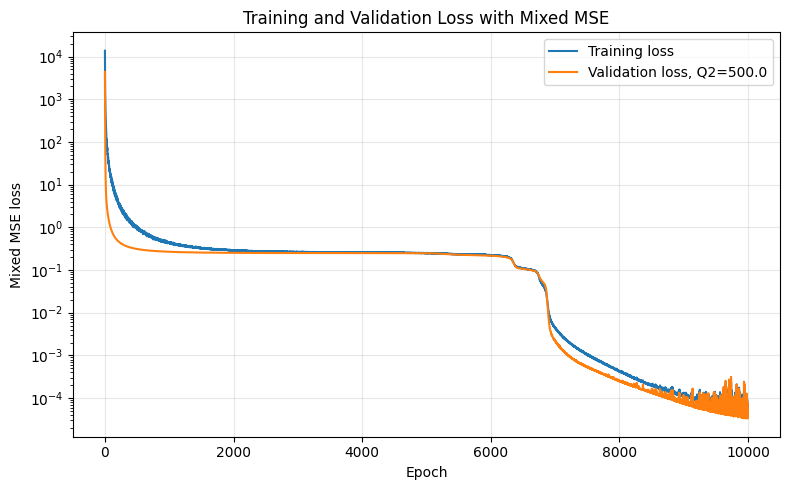

In [9]:
plt.figure(figsize=(8, 5))

plt.plot(train_losses, label="Training loss")
plt.plot(val_losses, label=f"Validation loss, Q2={VAL_Q2}")

plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Mixed MSE loss")
plt.title("Training and Validation Loss with Mixed MSE")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Comparing the neural network with the original PDF bands

In this cell, I compare the neural network predictions with the original PDF data for all selected `Q²` values.

The shaded regions represent the uncertainty bands from the PDF replicas.  
The median curves represent the central PDF values.  
The neural network curves show the model predictions.

This plot helps visually check whether the neural network has learned the general shape of the `uv` and `dv` distributions.

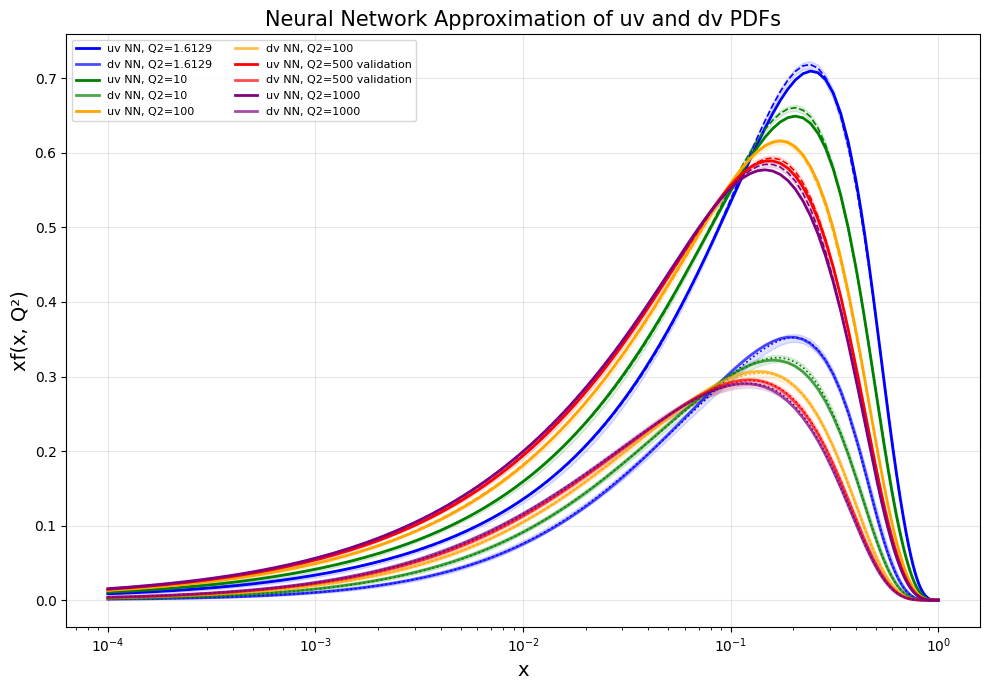

In [10]:
model.eval()

colors = {
    1.6129: "blue",
    10: "green",
    100: "orange",
    500: "red",
    1000: "purple"
}

fig, ax = plt.subplots(figsize=(10, 7))

for q2 in Q2_vals:

    color = colors[q2]

    uv = treypdf[q2]['uv']
    dv = treypdf[q2]['dv']

    uv_lower = np.quantile(uv, 0.025, axis=0)
    uv_upper = np.quantile(uv, 0.975, axis=0)
    uv_median = np.median(uv, axis=0)

    dv_lower = np.quantile(dv, 0.025, axis=0)
    dv_upper = np.quantile(dv, 0.975, axis=0)
    dv_median = np.median(dv, axis=0)

    # Inputs for this Q2
    inputs = np.stack([
        np.log(X),
        np.full_like(X, np.log(q2))
    ], axis=1)

    inputs_tensor = torch.tensor(inputs, dtype=torch.float32).to(device)

    with torch.no_grad():
        prediction = model(inputs_tensor).cpu().numpy()

    uv_pred = prediction[:, 0]
    dv_pred = prediction[:, 1]

    val_label = " validation" if q2 == VAL_Q2 else ""

    # UV band and prediction
    ax.fill_between(X, uv_lower, uv_upper, color=color, alpha=0.12)
    ax.plot(X, uv_median, color=color, linestyle="--", linewidth=1.2)
    ax.plot(X, uv_pred, color=color, linewidth=2, label=f"uv NN, Q2={q2}{val_label}")

    # DV band and prediction
    ax.fill_between(X, dv_lower, dv_upper, color=color, alpha=0.12)
    ax.plot(X, dv_median, color=color, linestyle=":", linewidth=1.2)
    ax.plot(X, dv_pred, color=color, linewidth=2, alpha=0.7, label=f"dv NN, Q2={q2}{val_label}")

ax.set_xscale("log")
ax.set_xlabel("x", fontsize=14)
ax.set_ylabel("xf(x, Q²)", fontsize=14)
ax.set_title("Neural Network Approximation of uv and dv PDFs", fontsize=15)

ax.grid(alpha=0.3)
ax.legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.show()

### Detailed comparison at one Q² value

In this cell, I focus on one value of `Q²`, usually `Q² = 500`.  
This is useful because `Q² = 500` was used as the validation scale, meaning the model did not train directly on it.

The plot compares the real PDF uncertainty bands, the median curves, and the neural network predictions for both `uv` and `dv`.

This gives a clearer view of how well the model generalizes to a new energy scale.

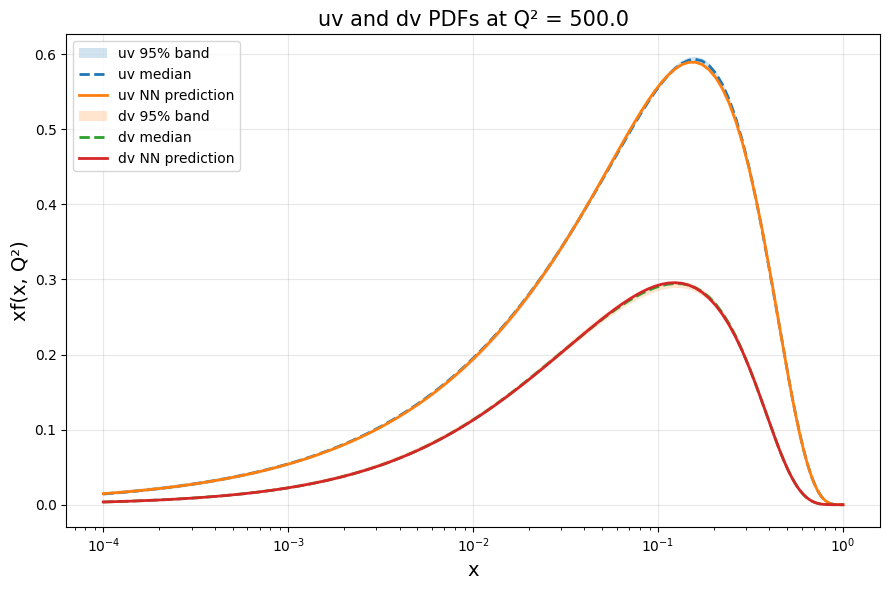

In [11]:
q2 = 500.0

model.eval()

uv = treypdf[q2]['uv']
dv = treypdf[q2]['dv']

uv_lower = np.quantile(uv, 0.025, axis=0)
uv_upper = np.quantile(uv, 0.975, axis=0)
uv_median = np.median(uv, axis=0)

dv_lower = np.quantile(dv, 0.025, axis=0)
dv_upper = np.quantile(dv, 0.975, axis=0)
dv_median = np.median(dv, axis=0)

inputs = np.stack([
    np.log(X),
    np.full_like(X, np.log(q2))
], axis=1)

inputs_tensor = torch.tensor(inputs, dtype=torch.float32).to(device)

with torch.no_grad():
    prediction = model(inputs_tensor).cpu().numpy()

uv_pred = prediction[:, 0]
dv_pred = prediction[:, 1]

plt.figure(figsize=(9, 6))

plt.fill_between(X, uv_lower, uv_upper, alpha=0.2, label="uv 95% band")
plt.plot(X, uv_median, linestyle="--", linewidth=2, label="uv median")
plt.plot(X, uv_pred, linewidth=2, label="uv NN prediction")

plt.fill_between(X, dv_lower, dv_upper, alpha=0.2, label="dv 95% band")
plt.plot(X, dv_median, linestyle="--", linewidth=2, label="dv median")
plt.plot(X, dv_pred, linewidth=2, label="dv NN prediction")

plt.xscale("log")
plt.xlabel("x", fontsize=14)
plt.ylabel("xf(x, Q²)", fontsize=14)
plt.title(f"uv and dv PDFs at Q² = {q2}", fontsize=15)

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

### Measuring prediction coverage inside the uncertainty band

In this cell, I calculate how often the neural network prediction falls inside the 95% PDF uncertainty band.

This gives a quantitative measure of performance.  
Instead of only checking visually, I can measure whether the model's predictions are consistent with the range of possible PDF replicas.

A high percentage means the neural network prediction is often within the uncertainty band.

In [12]:
model.eval()

print("Percentage of NN predictions inside the 95% PDF band")
print()
print(f"{'Q2':>10} | {'uv coverage':>12} | {'dv coverage':>12}")
print("-" * 42)

for q2 in Q2_vals:

    uv = treypdf[q2]['uv']
    dv = treypdf[q2]['dv']

    uv_lower = np.quantile(uv, 0.025, axis=0)
    uv_upper = np.quantile(uv, 0.975, axis=0)

    dv_lower = np.quantile(dv, 0.025, axis=0)
    dv_upper = np.quantile(dv, 0.975, axis=0)

    inputs = np.stack([
        np.log(X),
        np.full_like(X, np.log(q2))
    ], axis=1)

    inputs_tensor = torch.tensor(inputs, dtype=torch.float32).to(device)

    with torch.no_grad():
        prediction = model(inputs_tensor).cpu().numpy()

    uv_pred = prediction[:, 0]
    dv_pred = prediction[:, 1]

    uv_coverage = np.mean((uv_pred >= uv_lower) & (uv_pred <= uv_upper)) * 100
    dv_coverage = np.mean((dv_pred >= dv_lower) & (dv_pred <= dv_upper)) * 100

    print(f"{q2:>10} | {uv_coverage:>11.1f}% | {dv_coverage:>11.1f}%")

Percentage of NN predictions inside the 95% PDF band

        Q2 |  uv coverage |  dv coverage
------------------------------------------
    1.6129 |        85.5% |        89.0%
        10 |        78.0% |        87.5%
       100 |        87.5% |        88.0%
       500 |        91.0% |        87.5%
      1000 |        88.0% |        87.0%


The coverage results measure the percentage of neural network predictions that fall inside the 95% uncertainty band constructed from the PDF replicas.

Compared with the original standard-MSE version, the softened relative-loss model improves coverage significantly. This suggests that scaling the error by the size of the target value helps the model treat small- and large-magnitude PDF regions more evenly.

A high coverage means that the neural network prediction is often consistent with the uncertainty range suggested by the PDF replicas. However, coverage alone is not sufficient, so I also analyze the error as a function of `x`.

### Error analysis as a function of x

To improve the evaluation, I analyze the absolute error between the neural network prediction and the median PDF curve as a function of `x`. This helps identify whether the model struggles more at small, intermediate, or large momentum fractions.

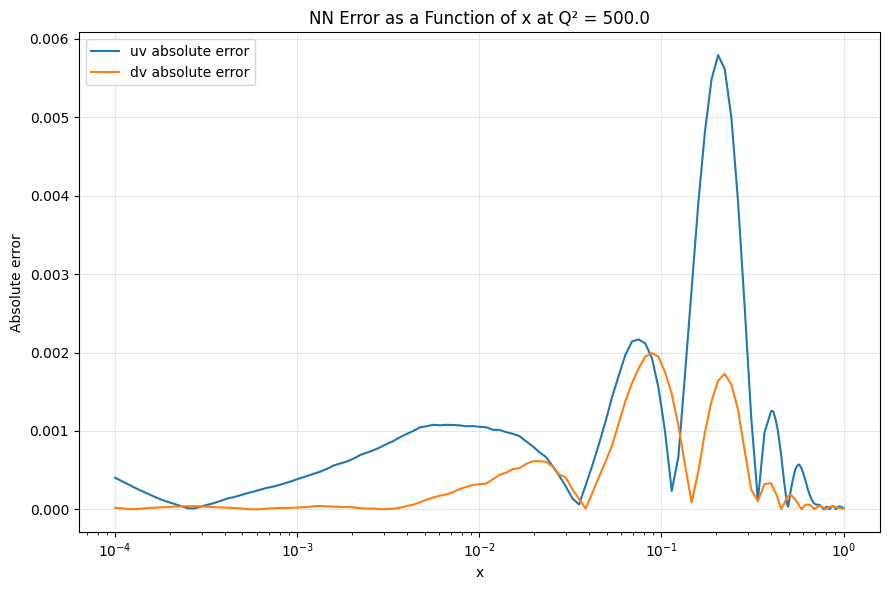

In [13]:
q2 = 500.0

model.eval()

uv = treypdf[q2]['uv']
dv = treypdf[q2]['dv']

uv_median = np.median(uv, axis=0)
dv_median = np.median(dv, axis=0)

inputs = np.stack([
    np.log(X),
    np.full_like(X, np.log(q2))
], axis=1)

inputs_tensor = torch.tensor(inputs, dtype=torch.float32).to(device)

with torch.no_grad():
    prediction = model(inputs_tensor).cpu().numpy()

uv_pred = prediction[:, 0]
dv_pred = prediction[:, 1]

# Absolute error
uv_abs_error = np.abs(uv_pred - uv_median)
dv_abs_error = np.abs(dv_pred - dv_median)

plt.figure(figsize=(9, 6))

plt.plot(X, uv_abs_error, label="uv absolute error")
plt.plot(X, dv_abs_error, label="dv absolute error")

plt.xscale("log")
plt.xlabel("x")
plt.ylabel("Absolute error")
plt.title(f"NN Error as a Function of x at Q² = {q2}")

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Error analysis as a function of x

The error plot shows where the neural network makes its largest mistakes across the momentum-fraction domain.

This is useful because visual agreement with the PDF bands does not clearly show whether the model struggles at small, intermediate, or large `x`.

In the softened relative-loss model, the error is generally more controlled across the domain than in the original standard-MSE model. The model improves especially in regions where the PDF values are smaller, although localized spikes can still appear in intermediate regions of `x`.

This analysis helps identify whether the model is only visually close or whether it is quantitatively accurate across the full `x` range.

# Leave-one-Q²-out validation using mixed loss

To test the model more strongly, I repeat the validation by holding out each `Q²` value one at a time. This checks whether the neural network can generalize across different energy scales, instead of only being tested at `Q² = 500`.

For each run, the model is retrained from scratch with one `Q²` value removed from the training set and used only for validation. This allows me to compare interpolation and extrapolation in `Q²`.

In [14]:
# Leave-one-Q²-out validation using Mixed MSE loss

N_EPOCHS_CV = 3000
BATCH_SIZE_CV = 512
EPS_CV = 1e-3

validation_results = {}

def mixed_loss(pred, target, alpha=0.7, eps=1e-3):
    mse = torch.mean((pred - target)**2)
    rel = torch.mean(((pred - target) / (torch.abs(target) + eps))**2)
    return alpha * mse + (1 - alpha) * rel

loss_fn = mixed_loss

for VAL_Q2 in Q2_vals:
    print(f"\nTraining with validation Q² = {VAL_Q2}")

    train_inputs = []
    train_targets = []
    val_inputs = []
    val_targets = []

    log_x = np.log(X)

    # Rebuild train/validation data for this held-out Q²
    for q2 in Q2_vals:
        uv = treypdf[q2]['uv']
        dv = treypdf[q2]['dv']

        uv_median = np.median(uv, axis=0)
        dv_median = np.median(dv, axis=0)

        inputs = np.stack([
            log_x,
            np.full_like(log_x, np.log(q2))
        ], axis=1)

        targets = np.stack([
            uv_median,
            dv_median
        ], axis=1)

        if q2 == VAL_Q2:
            val_inputs.append(inputs)
            val_targets.append(targets)
        else:
            train_inputs.append(inputs)
            train_targets.append(targets)

    train_X_cv = torch.tensor(np.concatenate(train_inputs), dtype=torch.float32).to(device)
    train_Y_cv = torch.tensor(np.concatenate(train_targets), dtype=torch.float32).to(device)

    val_X_cv = torch.tensor(np.concatenate(val_inputs), dtype=torch.float32).to(device)
    val_Y_cv = torch.tensor(np.concatenate(val_targets), dtype=torch.float32).to(device)

    # Fresh model for each validation Q²
    model_cv = PDFNN().to(device)

    optimizer = optim.Adam(model_cv.parameters(), lr=1e-3, weight_decay=1e-5)


    best_val_loss = float("inf")
    best_state = None

    N_train = train_X_cv.shape[0]

    for epoch in range(N_EPOCHS_CV):
        model_cv.train()

        permutation = torch.randperm(N_train, device=device)

        for start in range(0, N_train, BATCH_SIZE_CV):
            indices = permutation[start:start + BATCH_SIZE_CV]

            xb = train_X_cv[indices]
            yb = train_Y_cv[indices]

            optimizer.zero_grad()
            pred = model_cv(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            optimizer.step()

        model_cv.eval()
        with torch.no_grad():
            val_pred = model_cv(val_X_cv)
            val_loss = loss_fn(val_pred, val_Y_cv).item()

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model_cv.state_dict())

    validation_results[VAL_Q2] = best_val_loss
    print(f"Best mixed-loss validation for Q² = {VAL_Q2}: {best_val_loss:.6e}")


print("\nFinal leave-one-Q²-out results using mixed MSE:")
for q2, loss in validation_results.items():
    print(f"Validation Q² = {q2}: mixed loss = {loss:.6e}")


Training with validation Q² = 1.6129
Best mixed-loss validation for Q² = 1.6129: 4.014877e+01

Training with validation Q² = 10
Best mixed-loss validation for Q² = 10: 2.587724e-01

Training with validation Q² = 100
Best mixed-loss validation for Q² = 100: 2.531659e-01

Training with validation Q² = 500
Best mixed-loss validation for Q² = 500: 2.515783e-01

Training with validation Q² = 1000
Best mixed-loss validation for Q² = 1000: 2.471818e-01

Final leave-one-Q²-out results using mixed MSE:
Validation Q² = 1.6129: mixed loss = 4.014877e+01
Validation Q² = 10: mixed loss = 2.587724e-01
Validation Q² = 100: mixed loss = 2.531659e-01
Validation Q² = 500: mixed loss = 2.515783e-01
Validation Q² = 1000: mixed loss = 2.471818e-01


The leave-one-Q²-out validation shows that the model generalizes well for most energy scales, especially for Q² = 100, 500, and 1000, where the validation losses are around 10⁻⁵. However, the loss is much larger when Q² = 1.6129 is held out. This suggests that the lowest Q² value is harder for the neural network to predict because, in that case, the model must extrapolate below the training range instead of interpolating between known Q² values.

This result shows why testing only one validation scale is limited. Although the model performs well at Q² = 500, the leave-one-Q²-out test reveals that performance depends on which energy scale is excluded.

### Limited x-domain training experiment

The original plot uses 200 `x` values, ranging from very small `x` to `x = 1`. In this experiment, I train the model only on selected subranges of `x`, but I evaluate it on the full original `x` grid.

This tests whether the neural network can reproduce the correct PDF shape outside the region where it was trained.

If the model performs well inside the training interval but fails outside it, then the network is mainly interpolating well but struggling with extrapolation in `x`.

In [15]:
# Recreate the original x grid used in the plotting notebook

X = 10**np.linspace(-4, np.log10(0.4), 100)
X = np.append(X, np.linspace(0.4, 1, 101)[1:])

print("X shape:", X.shape)
print("Minimum x:", X.min())
print("Maximum x:", X.max())
def train_limited_x_model(
    x_min_train,
    x_max_train,
    val_q2=500.0,
    n_epochs=4000,
    batch_size=512,
    alpha=0.7,
    eps=1e-3,
    verbose=False
):
    x_mask_train = (X >= x_min_train) & (X <= x_max_train)

    X_limited = X[x_mask_train]
    log_x_limited = np.log(X_limited)

    train_inputs = []
    train_targets = []
    val_inputs = []
    val_targets = []

    for q2 in Q2_vals:
        uv = treypdf[q2]["uv"]
        dv = treypdf[q2]["dv"]

        uv_median = np.median(uv, axis=0)
        dv_median = np.median(dv, axis=0)

        uv_limited = uv_median[x_mask_train]
        dv_limited = dv_median[x_mask_train]

        inputs = np.stack([
            log_x_limited,
            np.full_like(log_x_limited, np.log(q2))
        ], axis=1)

        targets = np.stack([
            uv_limited,
            dv_limited
        ], axis=1)

        if q2 == val_q2:
            val_inputs.append(inputs)
            val_targets.append(targets)
        else:
            train_inputs.append(inputs)
            train_targets.append(targets)

    train_X_lim = torch.tensor(np.concatenate(train_inputs), dtype=torch.float32).to(device)
    train_Y_lim = torch.tensor(np.concatenate(train_targets), dtype=torch.float32).to(device)

    val_X_lim = torch.tensor(np.concatenate(val_inputs), dtype=torch.float32).to(device)
    val_Y_lim = torch.tensor(np.concatenate(val_targets), dtype=torch.float32).to(device)

    model_lim = PDFNN().to(device)
    optimizer = optim.Adam(model_lim.parameters(), lr=1e-3, weight_decay=1e-5)

    def mixed_loss(pred, target, alpha=alpha, eps=eps):
        mse = torch.mean((pred - target)**2)
        rel = torch.mean(((pred - target) / (torch.abs(target) + eps))**2)
        return alpha * mse + (1 - alpha) * rel

    loss_fn = mixed_loss

    best_val_loss = float("inf")
    best_state = None

    n_train = train_X_lim.shape[0]

    for epoch in range(1, n_epochs + 1):
        model_lim.train()

        permutation = torch.randperm(n_train, device=device)
        epoch_loss = 0.0
        n_batches = 0

        for start in range(0, n_train, batch_size):
            indices = permutation[start:start + batch_size]

            xb = train_X_lim[indices]
            yb = train_Y_lim[indices]

            optimizer.zero_grad()
            pred = model_lim(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            n_batches += 1

        epoch_loss /= max(1, n_batches)

        model_lim.eval()
        with torch.no_grad():
            val_pred = model_lim(val_X_lim)
            val_loss = loss_fn(val_pred, val_Y_lim).item()

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model_lim.state_dict())

        if verbose and epoch % 500 == 0:
            print(f"Epoch {epoch}: train loss={epoch_loss:.3e}, val loss={val_loss:.3e}")

    model_lim.load_state_dict(best_state)
    model_lim.eval()

    coverage_results = {}

    for q2 in Q2_vals:
        uv = treypdf[q2]["uv"]
        dv = treypdf[q2]["dv"]

        uv_lower = np.quantile(uv, 0.025, axis=0)
        uv_upper = np.quantile(uv, 0.975, axis=0)
        dv_lower = np.quantile(dv, 0.025, axis=0)
        dv_upper = np.quantile(dv, 0.975, axis=0)

        full_inputs = np.stack([
            np.log(X),
            np.full_like(X, np.log(q2))
        ], axis=1)

        full_inputs_tensor = torch.tensor(full_inputs, dtype=torch.float32).to(device)

        with torch.no_grad():
            pred_full = model_lim(full_inputs_tensor).cpu().numpy()

        uv_pred = pred_full[:, 0]
        dv_pred = pred_full[:, 1]

        uv_inside = (uv_pred >= uv_lower) & (uv_pred <= uv_upper)
        dv_inside = (dv_pred >= dv_lower) & (dv_pred <= dv_upper)

        inside_mask = x_mask_train
        outside_mask = ~x_mask_train

        coverage_results[q2] = {
            "uv_full": 100 * np.mean(uv_inside),
            "dv_full": 100 * np.mean(dv_inside),
            "uv_inside": 100 * np.mean(uv_inside[inside_mask]),
            "dv_inside": 100 * np.mean(dv_inside[inside_mask]),
            "uv_outside": 100 * np.mean(uv_inside[outside_mask]) if np.any(outside_mask) else np.nan,
            "dv_outside": 100 * np.mean(dv_inside[outside_mask]) if np.any(outside_mask) else np.nan,
        }

    return {
        "model": model_lim,
        "x_min_train": x_min_train,
        "x_max_train": x_max_train,
        "x_mask_train": x_mask_train,
        "best_val_loss": best_val_loss,
        "coverage": coverage_results
    }

X shape: (200,)
Minimum x: 0.0001
Maximum x: 1.0


In [16]:
x_domain_experiments = [
    (1e-4, 1.0, "Full x range"),
    (1e-3, 1.0, "Remove very small x"),
    (1e-4, 0.7, "Remove high x"),
    (1e-3, 0.7, "Remove both edges"),
    (1e-2, 0.7, "Strongly restricted x range")
]

limited_x_results = {}

for x_min, x_max, label in x_domain_experiments:
    print(f"\nTraining experiment: {label}")
    print(f"x range: [{x_min}, {x_max}]")

    result = train_limited_x_model(
        x_min_train=x_min,
        x_max_train=x_max,
        val_q2=500.0,
        n_epochs=10000,
        batch_size=512,
        alpha=0.7,
        eps=1e-3,
        verbose=False
    )

    limited_x_results[label] = result

    print(f"Best validation loss: {result['best_val_loss']:.6e}")

    q2 = 500.0
    cov = result["coverage"][q2]

    print(
        f"Q²={q2}: "
        f"uv full={cov['uv_full']:.1f}%, dv full={cov['dv_full']:.1f}%, "
        f"uv inside={cov['uv_inside']:.1f}%, dv inside={cov['dv_inside']:.1f}%, "
        f"uv outside={cov['uv_outside']:.1f}%, dv outside={cov['dv_outside']:.1f}%"
    )


Training experiment: Full x range
x range: [0.0001, 1.0]
Best validation loss: 4.123480e-05
Q²=500.0: uv full=93.5%, dv full=88.0%, uv inside=93.5%, dv inside=88.0%, uv outside=nan%, dv outside=nan%

Training experiment: Remove very small x
x range: [0.001, 1.0]
Best validation loss: 5.110019e-05
Q²=500.0: uv full=80.5%, dv full=80.5%, uv inside=92.4%, dv inside=86.0%, uv outside=7.1%, dv outside=46.4%

Training experiment: Remove high x
x range: [0.0001, 0.7]
Best validation loss: 8.354432e-06
Q²=500.0: uv full=77.5%, dv full=79.0%, uv inside=100.0%, dv inside=100.0%, uv outside=10.0%, dv outside=16.0%

Training experiment: Remove both edges
x range: [0.001, 0.7]
Best validation loss: 2.188513e-05
Q²=500.0: uv full=59.5%, dv full=69.0%, uv inside=95.1%, dv inside=100.0%, uv outside=3.8%, dv outside=20.5%

Training experiment: Strongly restricted x range
x range: [0.01, 0.7]
Best validation loss: 1.312899e-05
Q²=500.0: uv full=49.5%, dv full=51.5%, uv inside=100.0%, dv inside=100.0%, 

### Interpretation of the limited x-domain experiment

The limited x-domain experiment shows that the neural network performs well inside the region where it is trained, but its ability to extrapolate outside that region is limited. When the model is trained on the full x range, the coverage is high, around 90% for uv and 88% for dv. However, when small-x or large-x regions are excluded from training, the inside-domain coverage remains high while the outside-domain coverage drops sharply. This suggests that the model mainly learns to interpolate within the training x-domain and does not automatically recover the correct PDF shape in excluded regions.
The high inside coverage but low outside coverage indicates that good validation performance inside the training domain does not guarantee reliable extrapolation in x.

In [17]:
save_path = "/content/drive/MyDrive/uv_dv_pdf_nn_model_mixed_loss.pt"

torch.save({
    "model_state_dict": model.state_dict(),
    "Q2_vals": Q2_vals,
    "main_VAL_Q2": 500.0,
    "train_losses": train_losses,
    "val_losses": val_losses,
    "notes": "NN trained on median uv and dv valence PDFs using mixed loss: 0.7*MSE + 0.3*relative_loss."
}, save_path)

print("Model saved to:", save_path)

Model saved to: /content/drive/MyDrive/uv_dv_pdf_nn_model_mixed_loss.pt
